In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

from torrent_sim.config import default_config
from torrent_sim.core.engine import run_timestep_sim
from torrent_sim.viz import plot_basic_overview, plot_swarm_snapshot


## **Over-time Viz**

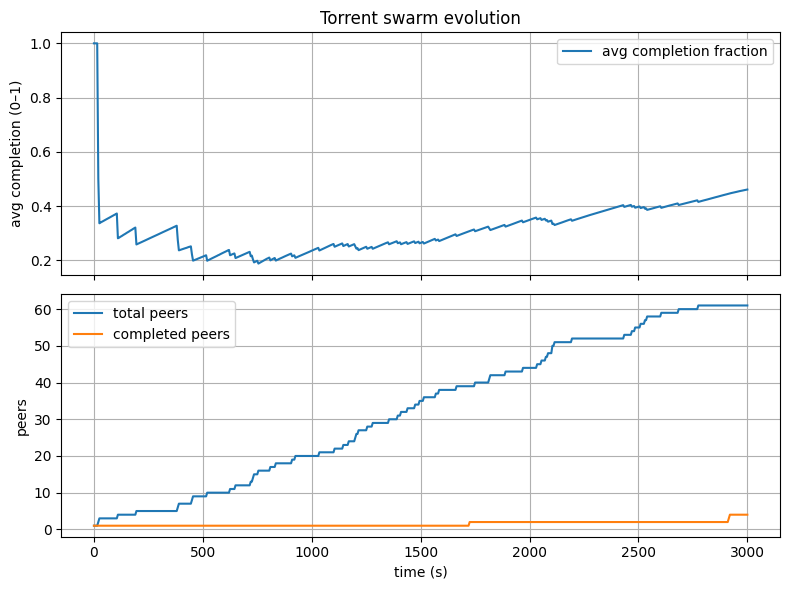

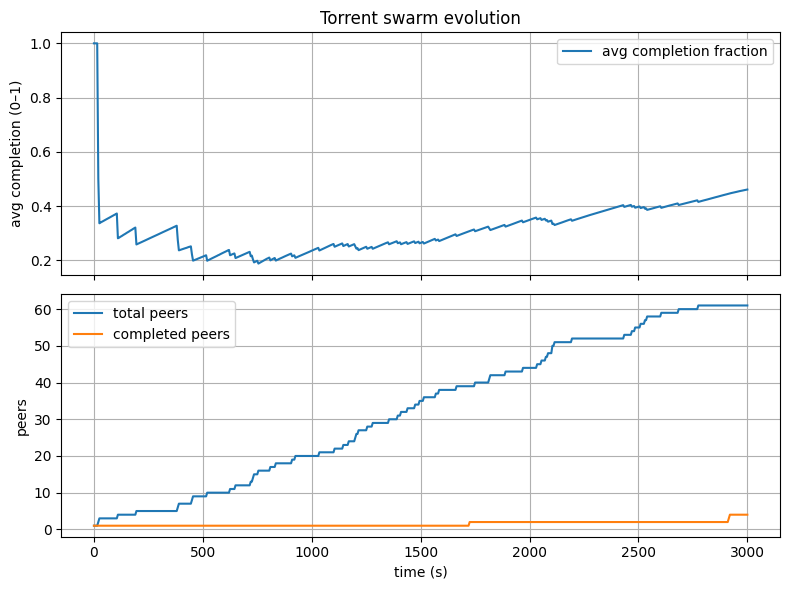

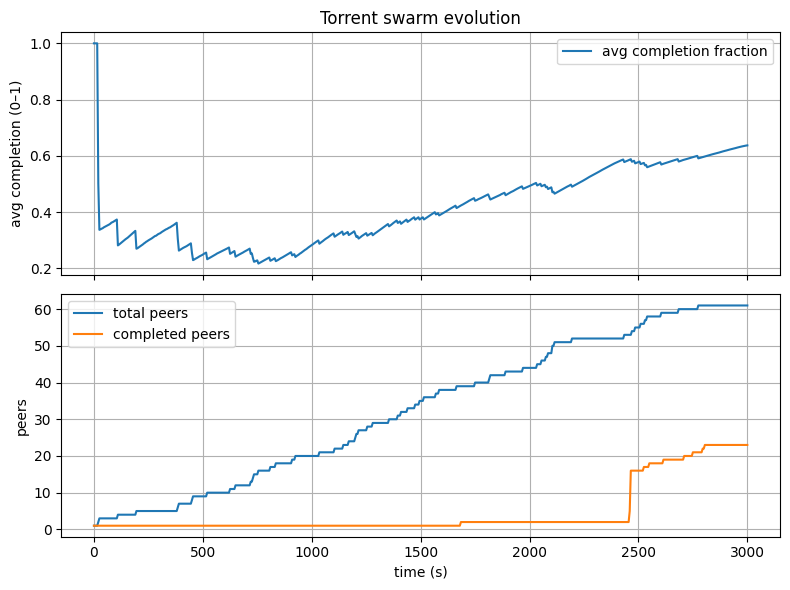

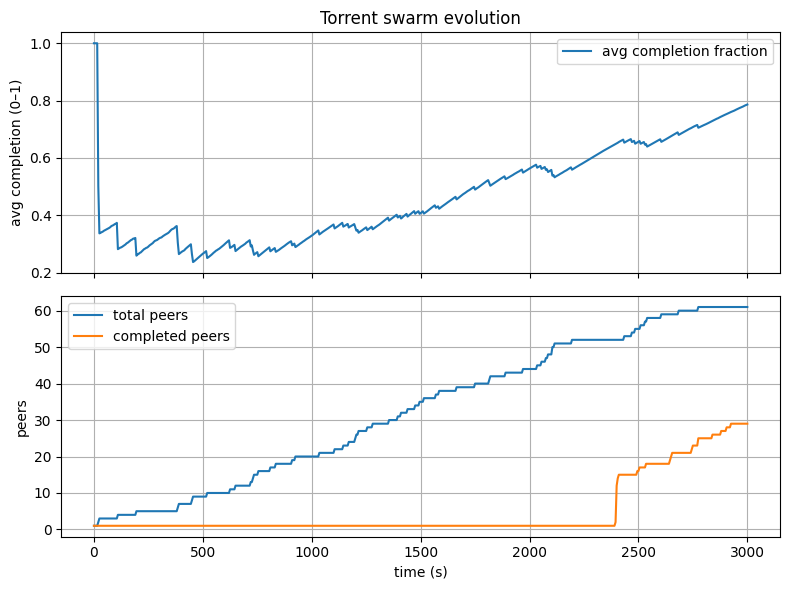

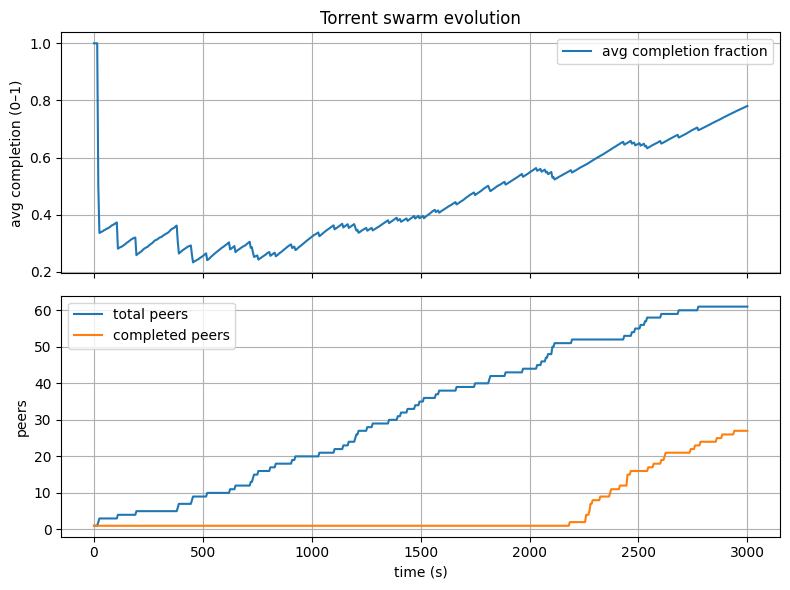

In [3]:
for param in [1,2,4,8,12]:
    cfg = default_config()
    # cfg.file.file_size_mb = 100.0
    # cfg.file.piece_size_mb = 1.0
    cfg.time.max_time = 3000.0
    cfg.time.dt = 1.0
    cfg.arrival.max_peers = 400
    cfg.arrival.arrival_rate = 1/(1*60)  # 1 peer every 2 minutes
    cfg.bandwidth.max_concurrent_downloads = 2
    cfg.graph.avg_degree=param
    # cfg.

    result = run_timestep_sim(cfg, np.random.default_rng(42))

    plot_basic_overview(result)
    # Network snapshot at final state
    # plot_swarm_snapshot(result, layout="spring",show_topology=True)

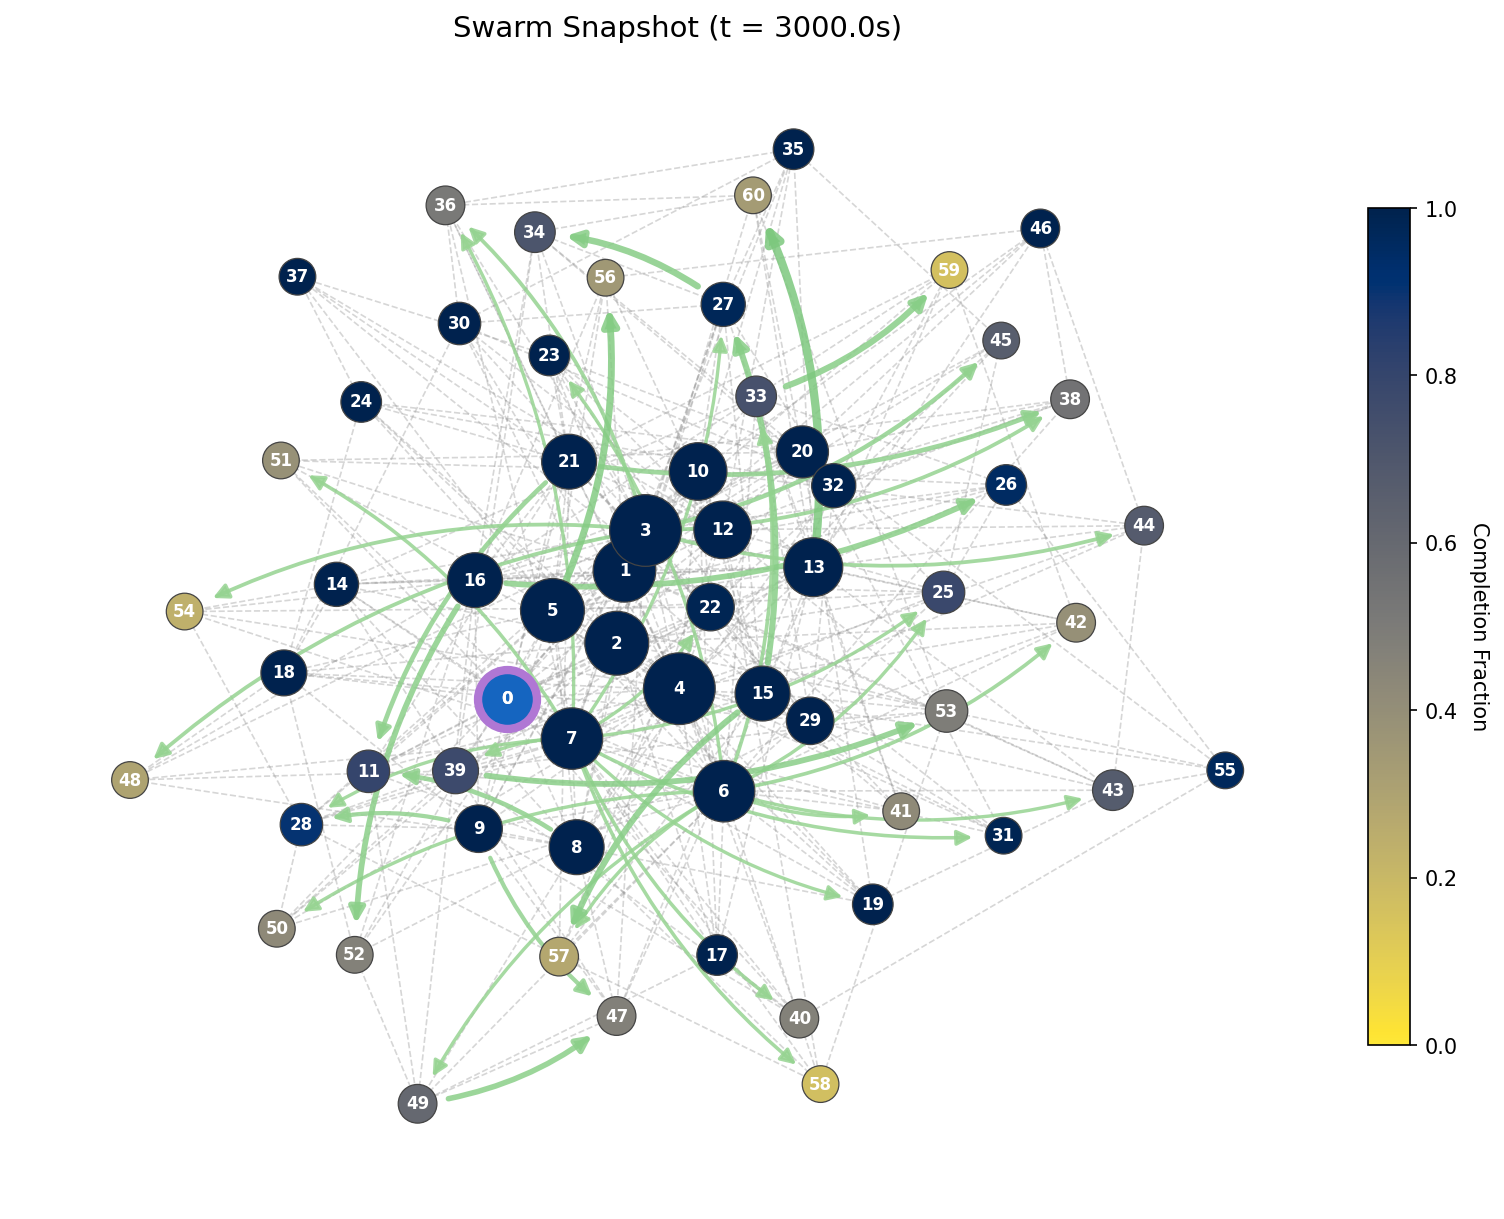

<Axes: title={'center': 'Swarm Snapshot (t = 3000.0s)'}>

In [9]:

# cfg = default_config()
# # cfg.file.file_size_mb = 100.0
# # cfg.file.piece_size_mb = 1.0
# cfg.time.max_time = 3000.0
# cfg.time.dt = 1.0
# cfg.arrival.max_peers = 400
# cfg.arrival.arrival_rate = 1/(1*60)  # 1 peer every 2 minutes
# cfg.bandwidth.max_concurrent_downloads = 5

# result = run_timestep_sim(cfg, np.random.default_rng(42))

# plot_basic_overview(result)
# # Network snapshot at final state
plot_swarm_snapshot(result, layout="spring",show_topology=True)


## **Network Viz**

In [6]:
peers = sorted(
    result.swarm.peers.values(),
    key=lambda p: (p.completed_time is None, p.completed_time if p.completed_time is not None else float('inf'))
)

for i, p in enumerate(peers):
    # print(p.peer_id, p.num_pieces_owned, p.completed_time, p.bandwidth.down_mbps,p.bandwidth.up_mbps)
    completed_str = f"{p.completed_time:.2f}" if p.completed_time is not None else "N/A"
    down_str = f"{p.bandwidth.down_mbps:.2f}" if getattr(p.bandwidth, "down_mbps", None) is not None else "N/A"
    up_str = f"{p.bandwidth.up_mbps:.2f}" if getattr(p.bandwidth, "up_mbps", None) is not None else "N/A"
    print(f"{p.peer_id} -- Pieces: {p.num_pieces_owned} -- Completed Time: {completed_str} -- Down: {down_str} Mbps -- Up: {up_str} Mbps")
    if i >= 9:
        break


0 -- Pieces: 1000 -- Completed Time: 0.00 -- Down: 61.26 Mbps -- Up: 6.88 Mbps
6 -- Pieces: 1000 -- Completed Time: 2420.00 -- Down: 50.44 Mbps -- Up: 4.41 Mbps
7 -- Pieces: 1000 -- Completed Time: 2420.00 -- Down: 42.76 Mbps -- Up: 65.52 Mbps
9 -- Pieces: 1000 -- Completed Time: 2421.00 -- Down: 61.28 Mbps -- Up: 4.72 Mbps
12 -- Pieces: 1000 -- Completed Time: 2421.00 -- Down: 40.52 Mbps -- Up: 9.15 Mbps
19 -- Pieces: 1000 -- Completed Time: 2421.00 -- Down: 52.44 Mbps -- Up: 12.26 Mbps
35 -- Pieces: 1000 -- Completed Time: 2421.00 -- Down: 140.94 Mbps -- Up: 110.68 Mbps
8 -- Pieces: 1000 -- Completed Time: 2423.00 -- Down: 48.46 Mbps -- Up: 11.26 Mbps
1 -- Pieces: 1000 -- Completed Time: 2428.00 -- Down: 60.67 Mbps -- Up: 11.76 Mbps
10 -- Pieces: 1000 -- Completed Time: 2432.00 -- Down: 39.73 Mbps -- Up: 14.97 Mbps


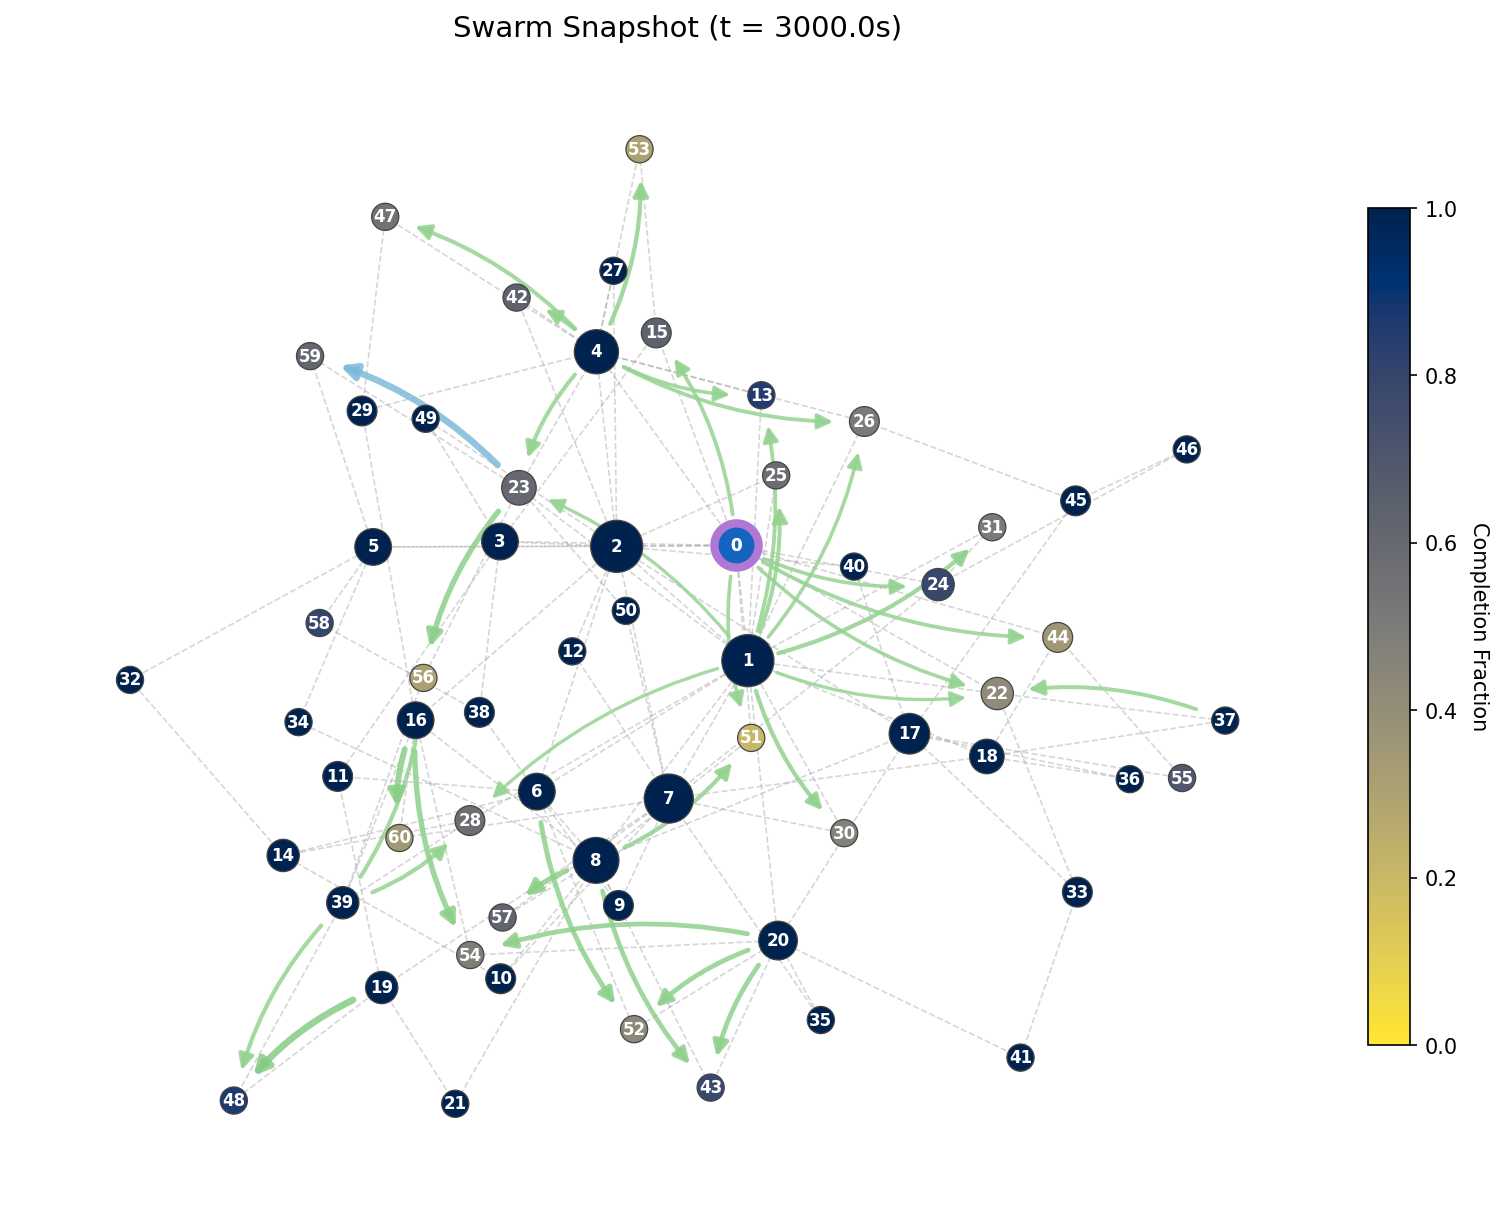

<Axes: title={'center': 'Swarm Snapshot (t = 3000.0s)'}>

In [7]:
# Network snapshot at final state
plot_swarm_snapshot(result, layout="spring",show_topology=True)


## **Animation Viz**

In [4]:
from matplotlib import pyplot as plt

from torrent_sim.config import default_config
from torrent_sim.core.engine import run_timestep_sim_with_frames
from torrent_sim.viz.animation import animate_swarm

# cfg = default_config()
# # cfg.file.file_size_mb = 100.0
# # cfg.file.piece_size_mb = 1.0
# cfg.time.max_time = 3000.0
# cfg.time.dt = 1.0
# cfg.arrival.max_peers = 400
# cfg.arrival.arrival_rate = 1/(1*60)  # 1 peer every 2 minutes
# cfg.bandwidth.max_concurrent_downloads = 5


trajectory = run_timestep_sim_with_frames(cfg, snapshot_interval=1.0)


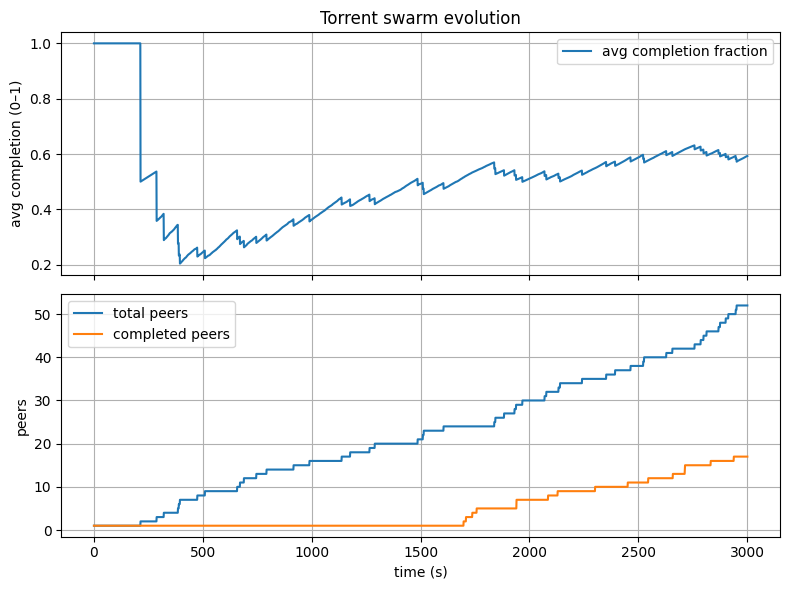

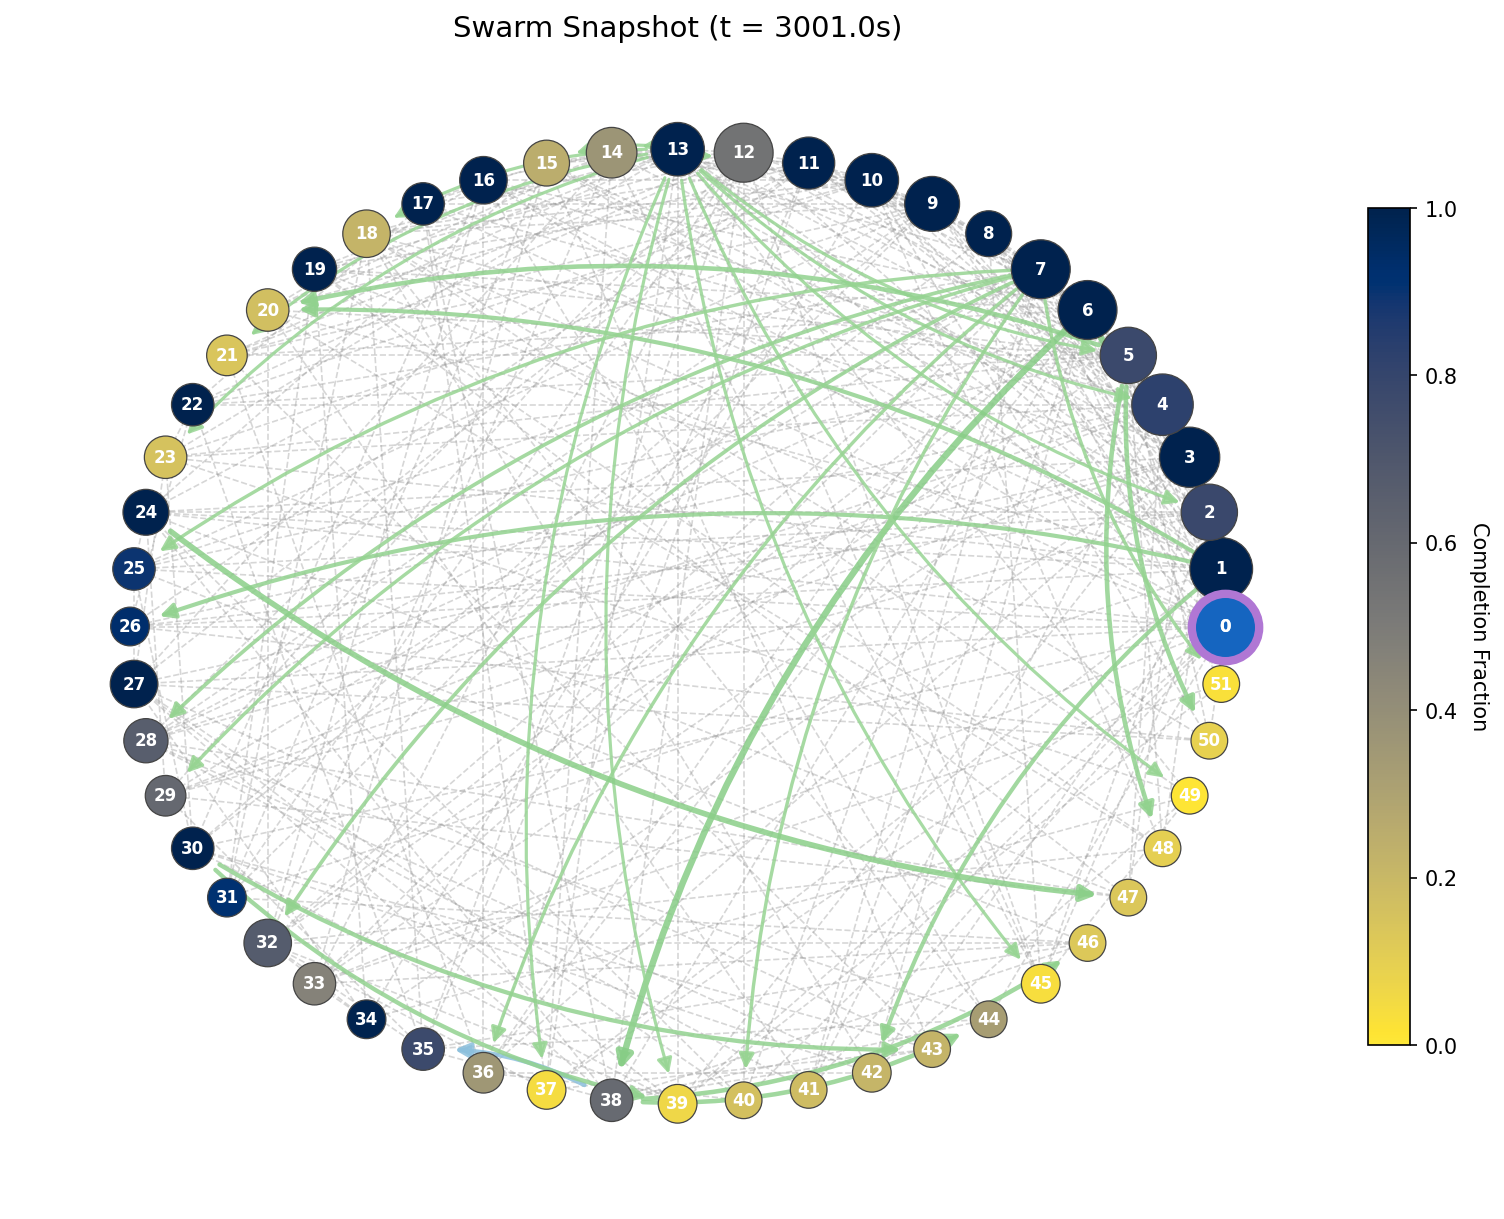

<Axes: title={'center': 'Swarm Snapshot (t = 3001.0s)'}>

In [5]:
# Network snapshot at final state
plot_basic_overview(trajectory.result)

plot_swarm_snapshot(trajectory.result, layout="circular",show_topology=True)


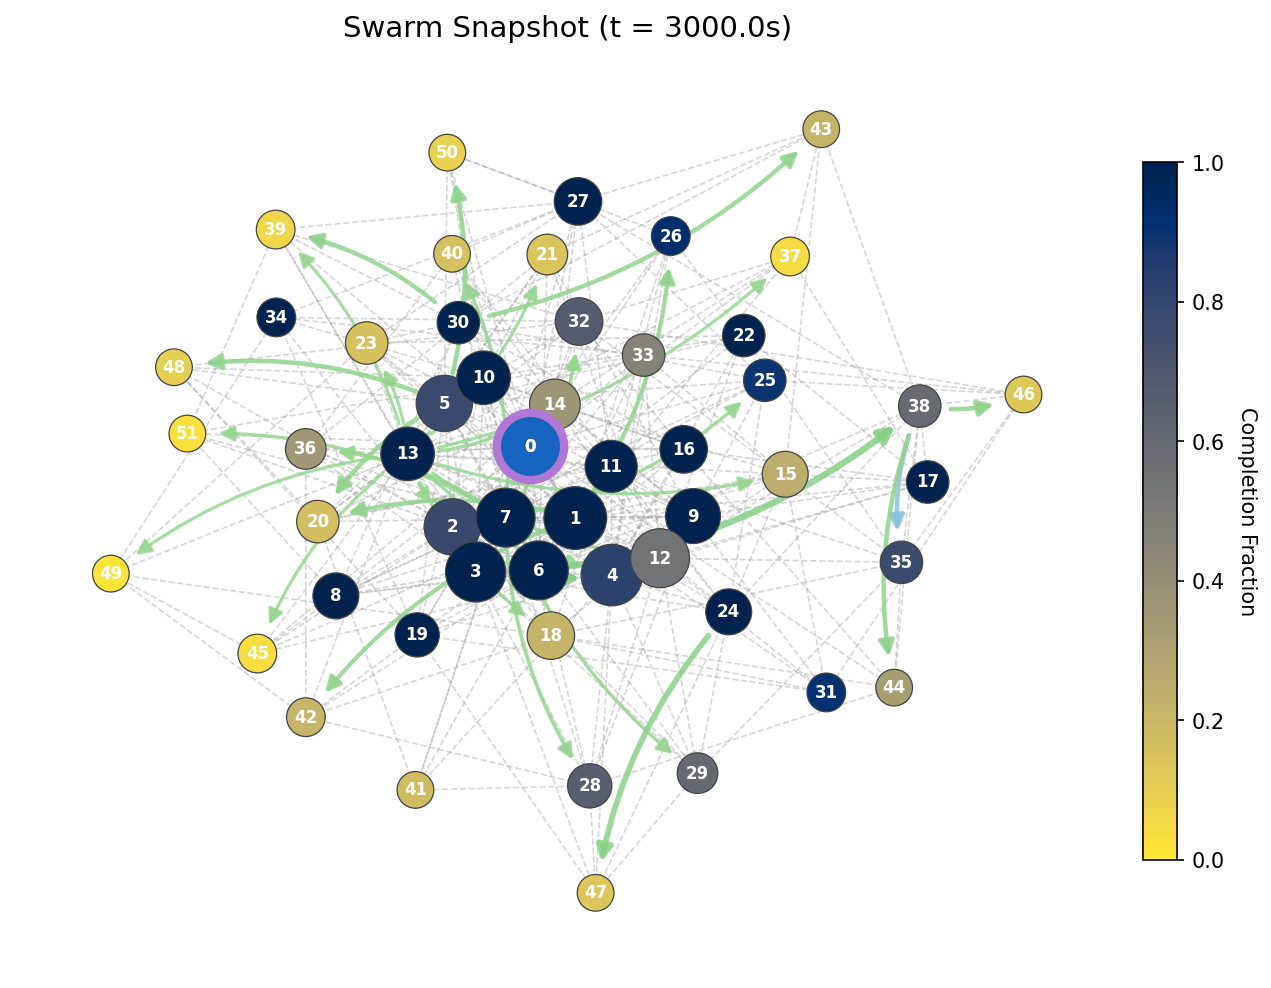

In [6]:
anim = animate_swarm(
    trajectory,
    layout="spring",
    interval_ms=25,
    show_topology=True,
    save_path="swarm.mp4"
)
plt.show()
